# SBD POC3 — local fixture run

Reads SBD data straight off local disk (`fixtures/sbd_poc3/`) instead of
the `data-exchange-demo-poc3-inbound` S3 bucket, which is still blocked on
a Unity Catalog external-location grant as of 2026-08-25.

Expects one already-combined dataframe (`sbd_poc3.parquet` or `.csv`) in
this repo's own column shape — see `fixtures/sbd_poc3/README.md`.
`scripts/assemble_sbd_fixture.py` builds it from SBD's raw flat files
(join logic mirrors Sebastian Urbina's `sbd-poc` pipeline — see that
script's docstring for exactly which defaults/assumptions it applies).

**Note on this rewrite:** the original version of this notebook called a
`Portfolio.from_dataframe(...).simulate(...)` API that doesn't exist in
this package (`replenishment/__init__.py` is empty — see `io_.py`'s module
docstring: that higher-level wrapper was never ported). This version uses
the actual API, following the same calibrate-then-simulate pattern as
`stock_replenishment_example.ipynb`: per-article safety-stock factor
calibration on a backtest window, then simulation over an evaluation
window with a `ReorderPointTrigger` policy.

**Scope:** the fixture covers ~66K materials. Calibrating+simulating all
of them here would take a while and isn't the point of a fixture-run demo
— this notebook runs the same pipeline on the top `N` materials by total
demand volume. Swap `TOP_N` for a smaller/larger cut, or drop the
`.head(TOP_N)` entirely to run the full universe as a batch job.

In [1]:
from pathlib import Path

import pandas as pd

FIXTURE_DIR = Path("../fixtures/sbd_poc3")
parquet_path = FIXTURE_DIR / "sbd_poc3.parquet"
csv_path = FIXTURE_DIR / "sbd_poc3.csv"

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
elif csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(
        f"No fixture at {parquet_path} or {csv_path} — see fixtures/sbd_poc3/README.md "
        "for the expected file and columns."
    )

df.head()

,unique_id,ds,demand,forecast,lead_time,holding_cost_per_unit,stockout_cost_per_unit,order_cost_per_order,current_stock
0,00 20 72 V04 XS,2025-03-01,189,184,2,1.532814,0.0,12.5,0
1,00 20 72 V04 XS,2025-04-01,8,57,2,1.532814,0.0,12.5,0
2,00 20 72 V04 XS,2025-05-01,19,9,2,1.532814,0.0,12.5,0
3,00 20 72 V04 XS,2025-06-01,10,6,2,1.532814,0.0,12.5,0
4,00 20 72 V04 XS,2025-07-01,4,8,2,1.532814,0.0,12.5,0


### Adapt the fixture to the loader's row shape

The fixture carries this repo's 9-column contract (see the README). The
row loader (`standard_simulation_rows_from_dataframe`) additionally wants
`actuals` (ground truth for backtest periods) and `initial_on_hand`
(starting inventory for the simulation clock). We only have one demand
series and one on-hand snapshot — no separate forecast-vs-actual pair, no
on-hand time series — so `actuals` mirrors `demand` and `initial_on_hand`
mirrors `current_stock`. This is a fixture-shape adaptation, not a new
join; it stays in the notebook rather than the fixture contract.

In [2]:
TOP_N = 25

df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
df["actuals"] = df["demand"]
df["initial_on_hand"] = df["current_stock"]

top_ids = (
    df.groupby("unique_id")["demand"].sum().sort_values(ascending=False).head(TOP_N).index
)
demo_df = df[df["unique_id"].isin(top_ids)].copy()
print(f"{demo_df['unique_id'].nunique()} materials, {len(demo_df)} rows, "
      f"ds range {demo_df['ds'].min()} .. {demo_df['ds'].max()}")
demo_df.head()

25 materials, 500 rows, ds range 2024-05-01 .. 2026-01-01


,unique_id,ds,demand,forecast,lead_time,holding_cost_per_unit,stockout_cost_per_unit,order_cost_per_order,current_stock,actuals,initial_on_hand
5227,02356Z-PWR,2024-05-01,544000,168000,0,0.000925,0.020039,12.5,1488000,544000,1488000
5228,02356Z-PWR,2024-06-01,1142000,457000,0,0.000925,0.020039,12.5,1488000,1142000,1488000
5229,02356Z-PWR,2024-07-01,1428000,704000,0,0.000925,0.020039,12.5,1488000,1428000,1488000
5230,02356Z-PWR,2024-08-01,693000,321000,0,0.000925,0.020039,12.5,1488000,693000,1488000
5231,02356Z-PWR,2024-09-01,1018000,575000,0,0.000925,0.020039,12.5,1488000,1018000,1488000


In [3]:
from replenishment.io_ import (
    standard_simulation_rows_from_dataframe, standard_simulation_rows_to_dataframe,
    split_standard_simulation_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import SqrtHorizonSafetyStock
from replenishment.viz import plot_replenishment_decisions

review_period = 1
forecast_horizon = 1

# last 3 months per article = evaluation window; everything before = backtest window
cutoff = demo_df["ds"].max() - pd.DateOffset(months=3)
rows = standard_simulation_rows_from_dataframe(demo_df, cutoff=cutoff)
backtest_rows, evaluation_rows = split_standard_simulation_rows(rows)
print(f"{len(backtest_rows)} backtest rows, {len(evaluation_rows)} evaluation rows")

rows_df = standard_simulation_rows_to_dataframe(backtest_rows + evaluation_rows, library="pandas")

425 backtest rows, 75 evaluation rows


In [4]:
def _group_by_article(rows):
    grouped = {}
    for row in rows:
        grouped.setdefault(row.unique_id, []).append(row)
    for uid in grouped:
        grouped[uid].sort(key=lambda r: r.ds)
    return grouped

### Calibrate safety-stock factor per article, then simulate

Same pattern as `stock_replenishment_example.ipynb`: sweep a candidate
safety-stock factor against the backtest window (minimizing total
holding + stockout + ordering cost), then run the calibrated
`ReorderPointTrigger` policy forward over the evaluation window.

In [5]:
candidate_factors = [0.8, 1.0, 1.3, 1.65, 2.0]

backtest_by_article = _group_by_article(backtest_rows)
forecast_by_article = _group_by_article(evaluation_rows)

decision_rows = []
calibration_results = {}
for unique_id, article_backtest in backtest_by_article.items():
    demand = [r.demand for r in article_backtest]
    actuals = [r.actuals for r in article_backtest]
    forecast_values = [r.forecast for r in article_backtest]
    lead_time = article_backtest[0].lead_time

    def candidate_builder(factor, forecast_values=forecast_values, actuals=actuals, lead_time=lead_time):
        return ReplenishmentPolicy.reorder_point(
            forecast=TimeSeries.from_values(forecast_values),
            actuals=TimeSeries.from_values(actuals),
            safety_stock=SqrtHorizonSafetyStock(factor=factor),
            lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
        )

    result = optimize(
        candidate_builder=candidate_builder, candidate_values=candidate_factors,
        periods=len(article_backtest), demand=demand, initial_on_hand=article_backtest[0].initial_on_hand,
        lead_time=lead_time, holding_cost_per_unit=article_backtest[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_backtest[0].stockout_cost_per_unit,
        order_cost_per_order=article_backtest[0].order_cost_per_order,
    )
    calibration_results[unique_id] = result

    article_forecast_rows = forecast_by_article.get(unique_id, [])
    if not article_forecast_rows:
        continue
    eval_policy = candidate_builder(
        result.best_value, forecast_values=[r.forecast for r in article_forecast_rows], actuals=actuals,
    )
    current_stock = article_forecast_rows[0].current_stock
    simulation = simulate_replenishment(
        periods=len(article_forecast_rows), demand=[r.demand for r in article_forecast_rows],
        initial_on_hand=current_stock, lead_time=lead_time, policy=eval_policy,
        holding_cost_per_unit=article_forecast_rows[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_forecast_rows[0].stockout_cost_per_unit,
        order_cost_per_order=article_forecast_rows[0].order_cost_per_order,
    )
    for row, snapshot in zip(article_forecast_rows, simulation.snapshots):
        decision_rows.append(ReplenishmentDecisionRow(
            unique_id=unique_id, ds=row.ds, quantity=snapshot.order_placed,
            demand=snapshot.demand, incoming_stock=snapshot.received,
            starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
            on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=result.best_value,
        ))

eval_decisions_df = replenishment_decision_rows_to_dataframe(decision_rows, library="pandas")
eval_decisions_df.head()

,unique_id,ds,quantity,demand,forecast_quantity,forecast_quantity_lead_time,reorder_point,order_up_to,incoming_stock,starting_stock,...,current_stock,on_order,backorders,missed_sales,sigma,aggregation_window,review_period,forecast_horizon,rmse_window,percentile_target
0,02356Z-PWR,2025-11-01,0,92000,None,None,None,None,0,None,...,None,0,0,None,2.0,None,None,None,None,None
1,02356Z-PWR,2025-12-01,0,961000,None,None,None,None,0,None,...,None,0,0,None,2.0,None,None,None,None,None
2,02356Z-PWR,2026-01-01,1688496,877000,None,None,None,None,0,None,...,None,0,442000,None,2.0,None,None,None,None,None
3,02808-PWR,2025-11-01,0,299500,None,None,None,None,0,None,...,None,0,0,None,2.0,None,None,None,None,None
4,02808-PWR,2025-12-01,0,351900,None,None,None,None,0,None,...,None,0,0,None,2.0,None,None,None,None,None


### Plot one article

<Axes: title={'center': 'Replenishment for 02356Z-PWR'}, xlabel='Date', ylabel='Units'>

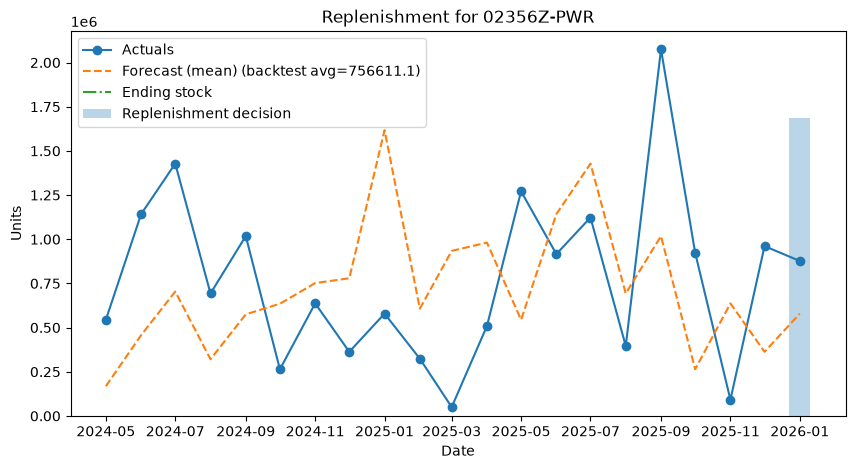

In [6]:
example_id = eval_decisions_df["unique_id"].iloc[0]
plot_replenishment_decisions(rows_df, eval_decisions_df, unique_id=example_id)